In [1]:
from ravex import MultiPlanetSystem
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.62 * u.solMass

# Define two planets
planet1 = {
    "mass": 3.575 * u.earthMass,
    "time_periastron": t.Time("2019-11-30T04:23:05.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.25,
    "orbital_period": 13.47 * u.day,
}

planet2 = {
    "mass": 8.0 * u.earthMass,
    "time_periastron": t.Time("2019-12-05T00:00:00.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.15,
    "orbital_period": 31.0 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1, planet2])

In [3]:
# Build a dense and regular time grid to sample the theoretical RV curve
n_model = 10000
span_days = 2 * planet2["orbital_period"].to_value(u.day)
start_time = t.Time("2020-01-01T00:00:00", format="isot", scale="utc")

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model, including the contribution of each planet
jd_model, rv_total, phases_model, phased_model, rv_by_planet = system.get_rvs(
    time_grid,
    include_per_planet=True
)

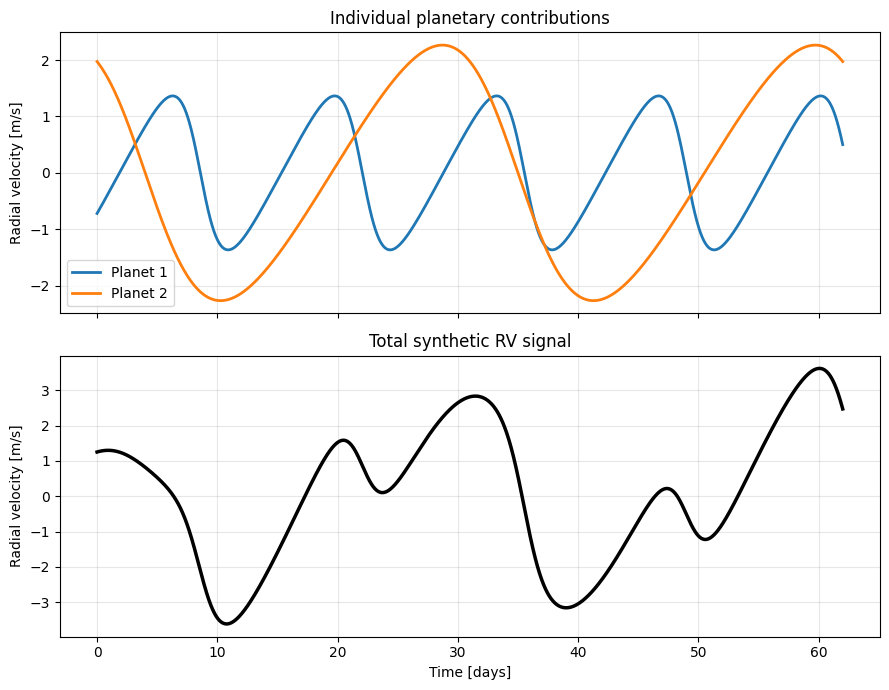

In [4]:
# Plot the individual planetary signals and the total RV curve
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Top panel: individual planetary signals
axes[0].plot(time_days, rv_by_planet["p0"], label="Planet 1", lw=2)
axes[0].plot(time_days, rv_by_planet["p1"], label="Planet 2", lw=2)
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Individual planetary contributions")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom panel: total RV signal
axes[1].plot(time_days, rv_total, color="black", lw=2.5)
axes[1].set_xlabel("Time [days]")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Total synthetic RV signal")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()